## 1. Importing Libraries

In [31]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## 2. Loading the Dataset

In [32]:
df = pd.read_csv("advertising.csv")

df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


## 3.Exploratory Data Analysis

In [33]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [34]:
df.tail()

,TV,Radio,Newspaper,Sales
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5
199,232.1,8.6,8.7,18.4


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [36]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [37]:
df.shape

(200, 4)

In [38]:
df.columns

Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [39]:
df.index

RangeIndex(start=0, stop=200, step=1)

In [40]:
df.isna().sum()/len("advertising.csv")

TV           0.0
Radio        0.0
Newspaper    0.0
Sales        0.0
dtype: float64

## 4. Checking Correlation

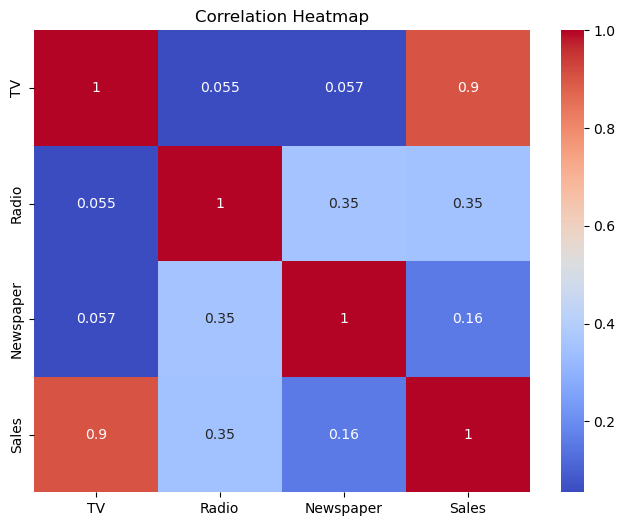

In [41]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

TV → Strong Positive Correlation

Radio → Moderate Positive Correlation

Newspaper → Weak Correlation

This means TV advertising impacts sales the most.

## 5. Data Visualization

 #### TV vs Sales

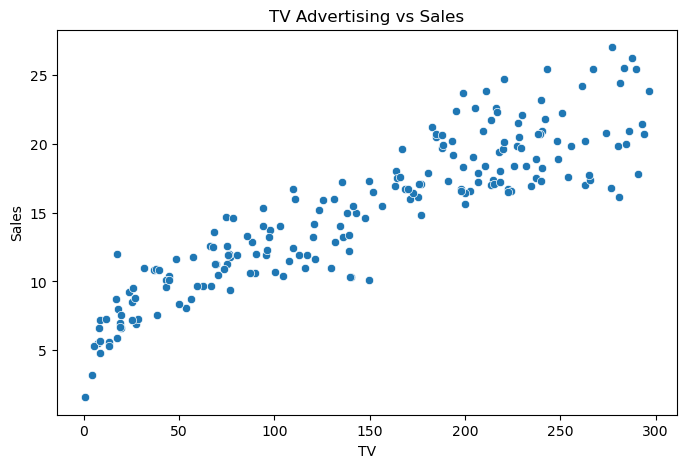

In [42]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='TV',
    y='Sales',
    data=df
)

plt.title("TV Advertising vs Sales")

plt.show()

## 6. Separating Feature and Target Variable

y -> Target variable

X -> Feature variable

In [43]:
y = df['Sales']
X = df.drop('Sales', axis=1)

## 7. Train-Test Split

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## 8. Model Building 

#### Linear Regression Model

In [45]:
lr = LinearRegression()

lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


#### Random Forest Model

In [46]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 9. Predictions 

#### Linear Model Predictions

In [47]:
lr_pred = lr.predict(X_test)

#### Random Forest Prediction

In [48]:
rf_pred = rf.predict(X_test)

## 10. Model Evaluaton

#### Linear Model Evaluation

In [49]:
print("Linear Regression Results")

print("MAE:", mean_absolute_error(y_test, lr_pred))

print("MSE:", mean_squared_error(y_test, lr_pred))

print("R2 Score:", r2_score(y_test, lr_pred))

Linear Regression Results
MAE: 1.274826210954934
MSE: 2.907756910271092
R2 Score: 0.9059011844150826


#### Random Forest Model Evaluation

In [50]:
print("Random Forest Results")

print("MAE:", mean_absolute_error(y_test, rf_pred))

print("MSE:", mean_squared_error(y_test, rf_pred))

print("R2 Score:", r2_score(y_test, rf_pred))

Random Forest Results
MAE: 0.9179999999999993
MSE: 1.4374328500000009
R2 Score: 0.9534827934927883


## 11. Model Comparison

In [51]:
lr_r2 = r2_score(y_test, lr_pred)

rf_r2 = r2_score(y_test, rf_pred)

comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'R2 Score': [lr_r2, rf_r2]
})

comparison

,Model,R2 Score
0,Linear Regression,0.905901
1,Random Forest,0.953483


## 12. Selecting Best Model

In [52]:
if rf_r2 > lr_r2:
    print("Random Forest is the Best Model")
else:
    print("Linear Regression is the Best Model")

Random Forest is the Best Model


## 13. Actual vs Predicted Sales 

In [53]:
comparison_df = pd.DataFrame({
    'Actual Sales': y_test,
    'Predicted Sales': rf_pred
})

comparison_df.head(10)

,Actual Sales,Predicted Sales
95,16.9,17.299
15,22.4,22.482
30,21.4,19.770
158,7.3,6.784
128,24.7,22.961
115,12.6,13.471
69,22.3,22.595
170,8.4,9.579
174,16.5,16.887
45,16.1,16.793


## 14. Actual vs Predicted Plot

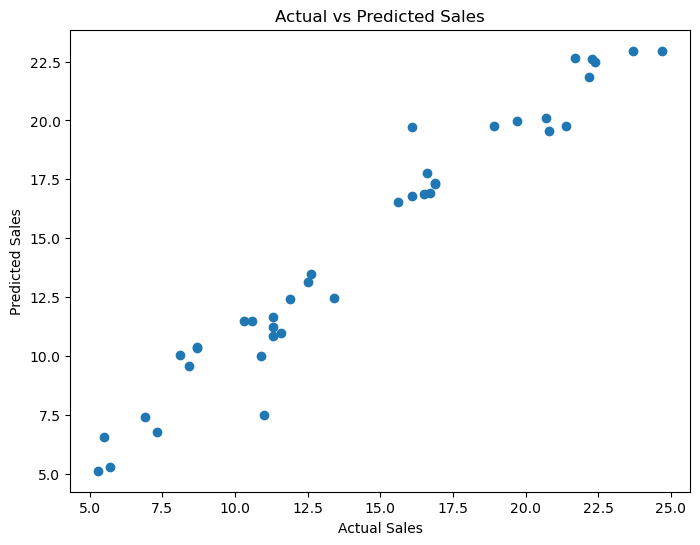

In [54]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    rf_pred
)

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()

## 15. Feature Importance

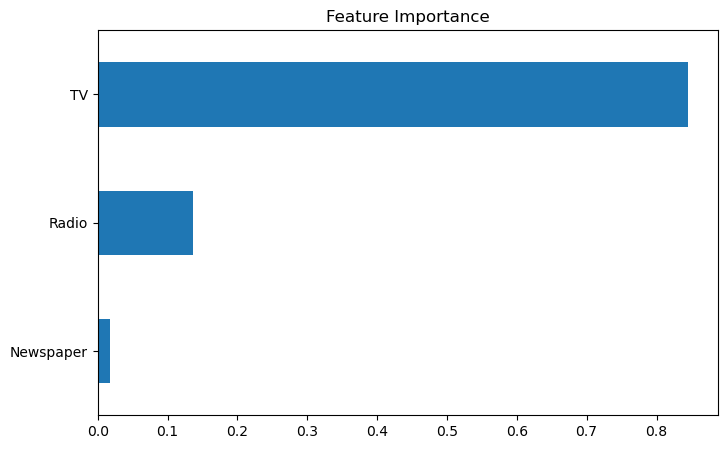

In [55]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.title("Feature Importance")

plt.show()

TV         Highest Impact

Radio      Medium Impact

Newspaper  Lowest Impact

## 16. Predict Future Sales

In [56]:
TV = 200
Radio = 40
Newspaper = 50

new_ad = pd.DataFrame(
    [[200, 40, 50]],
    columns=X.columns
)

future_sales = rf.predict(new_ad)

print("Predicted Sales:", future_sales[0])

Predicted Sales: 21.00599999999999


## 17. Conclusion

A Sales Prediction model was developed using advertising expenditure data.

The dataset was analyzed and visualized to understand the relationship between advertising channels and sales.

Two machine learning models were trained:
1. Linear Regression
2. Random Forest Regressor

After evaluation using MAE, MSE, and R² Score, the model with the higher R² Score was selected.

The analysis showed that TV advertising contributes the most to sales, followed by Radio advertising, while Newspaper advertising has the least impact.

The final model can be used to forecast future sales and support marketing budget decisions.